# 🐶 Dogs vs Cats: Feature Extraction and Analysis

## Introduction
This notebook implements an end-to-end machine learning pipeline for the **Dogs vs Cats** dataset. The objective is to utilize Deep Neural Networks (DNNs) to extract high-level feature representations from images and analyze them using both unsupervised and supervised techniques.

We utilize a pre-trained **ResNet50** architecture to transform raw images into feature vectors, followed by dimensionality reduction and analysis.

## 📋 Table of Contents

1. **Exploratory Data Analysis (EDA)**
   - Inspecting sample images from the dataset.

2. **Feature Vector Extraction**
   - Loading the pre-trained **ResNet50** model.
   - Extracting 2048-dimensional embeddings for each image.

3. **Data Pre-processing**
   - Normalization and Standardization of feature vectors.
   - Dimensionality Reduction using **PCA** (Principal Component Analysis).

4. **Clustering (Unsupervised Learning)**
   - Applying **K-Means** clustering on the latent feature space.
   - Evaluating cluster quality using Silhouette Scores and Davies-Bouldin Index.

5. **Classification (Supervised Learning)**
   - Training a **Support Vector Machine (SVM)** on the extracted features.
   - Training a **Linear Classifier** (Fine-tuning).
   - Evaluating performance using Accuracy, Precision, Recall, and F1-Score.

---

### Imports

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import torch
from torchvision.transforms import v2
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.io import decode_image, ImageReadMode
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Getting the Data

In [6]:
path = "/content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages"


# Dataset Exploration

In [7]:
images = []
labels = []
valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}
try:
    for foldr in os.listdir(path):
        # Skip hidden files like .DS_Store
        if foldr.startswith('.'): continue

        folder_full = os.path.join(path, foldr)
        if os.path.isdir(folder_full):
            for filee in os.listdir(folder_full):
                file_ext = os.path.splitext(filee.lower())[1]
                if file_ext in valid_ext:
                    # We store relative path "Cat/0.jpg"
                    images.append(os.path.join(filee))
                    labels.append(foldr)
except Exception as e:
    print(f'Error: {e}')
image_df = pd.DataFrame({
    'Images': images,
    'Labels': labels
})

In [8]:
print("shape =", image_df.shape)


shape = (24959, 2)


## Random Image Display

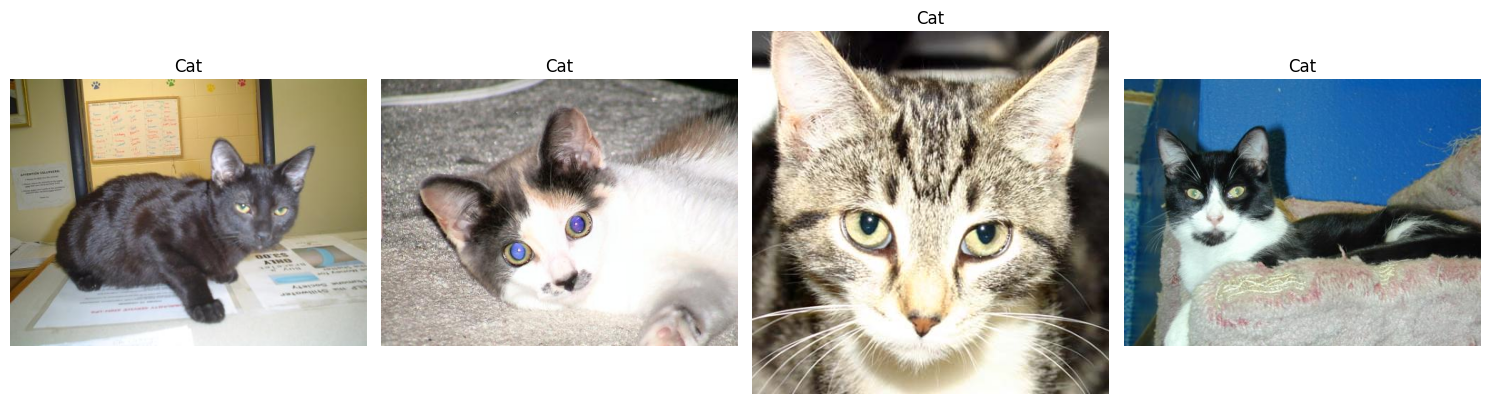

In [9]:
save_path = "/content/drive/MyDrive/SCC-451/plots"
os.makedirs(save_path, exist_ok=True)

# Number of random images to sample
num_samples = 4  # you can change this
sampled_rows = image_df.sample(n=num_samples, random_state=42)  # random sample

fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i, (_, row) in enumerate(sampled_rows.iterrows()):
    img_path = os.path.join(path, row['Labels'], row['Images'])
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Save image
    out_name = f"sample_{i+1}_{row['Labels']}.png"
    cv2.imwrite(os.path.join(save_path, out_name), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))

    # Plot
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['Labels']}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Feature Extraction using Resnet 50

In [10]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision.io import decode_image, ImageReadMode
from torchvision.models import resnet50, ResNet50_Weights
import os

# 1. Create a Custom Dataset Class
# This separates data loading from model inference, allowing PyTorch to parallelize it.
class ImageDataset(Dataset):
    def __init__(self, image_df, root_dir, transform=None):
        self.image_df = image_df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_df)

    def __getitem__(self, idx):
        row = self.image_df.iloc[idx]
        img_name = row['Images']
        label = row['Labels']
        img_path = os.path.join(self.root_dir,label ,img_name)

        try:
            # Load Image
            img = decode_image(img_path, mode=ImageReadMode.RGB)

            # Apply Transforms
            if self.transform:
                img = self.transform(img)

            return img, label, img_name # Return name to track errors if needed

        except Exception as e:
            # Handle corrupted images gracefully (return None)
            print(f"Error loading {img_path}: {e}")
            return None, None, None

# Custom collate function to filter out bad images (None) from a batch
def collate_fn(batch):
    batch = list(filter(lambda x: x[0] is not None, batch))
    if not batch:
        return torch.tensor([]), [], []
    return torch.utils.data.dataloader.default_collate(batch)


# 2. Optimized Feature Extraction Class
class FeatureExtractor:
    def __init__(self, path: str, image_df: pd.DataFrame) -> None:
        self.path = path
        self.image_df = image_df
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Running on: {self.device}")

        # Load Model
        self.weights = ResNet50_Weights.DEFAULT
        self.resnet_transforms = self.weights.transforms()
        self.model = resnet50(weights=self.weights)
        self.model.fc = torch.nn.Identity() # Remove classification head
        self.model.eval()
        self.model.to(self.device)

    def extract_features(self, batch_size=64, num_workers=4):
        # Setup Dataset and DataLoader
        dataset = ImageDataset(self.image_df, self.path, transform=self.resnet_transforms)

        # DataLoader handles the parallel loading and batching
        loader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers, # Critical for speed! Uses CPU cores to load data
            pin_memory=True,         # Critical for speed! Faster CPU->GPU transfer
            collate_fn=collate_fn    # Skips corrupted images
        )

        all_features = []
        all_labels = []

        print(f"Starting feature extraction on {self.device} with batch_size={batch_size}...")

        with torch.no_grad():
            for batch_idx, (images, labels, names) in enumerate(loader):
                if images.numel() == 0: continue # Skip empty batches

                # Move batch to GPU
                images = images.to(self.device)

                # Inference (Extract features for 64 images at once)
                # Enable mixed precision for extra speed (optional, safe for inference)
                with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):
                    features = self.model(images)

                # Move results to CPU and store
                all_features.append(features.cpu().numpy())
                all_labels.extend(labels)

                if batch_idx % 10 == 0:
                    print(f"Processed batch {batch_idx}/{len(loader)}")

        # Concatenate all batches into one large array
        print("Concatenating results...")
        features_array = np.vstack(all_features)

        # Create DataFrame
        df_result = pd.DataFrame(features_array)
        df_result['Label'] = all_labels


        return df_result

## Image Subset Sampling
Since we have way too many images, we'll only take a subset and train of around 5000 images. We will split using stratify

In [11]:
from sklearn.model_selection import train_test_split

# Calculate the desired fraction for the subset
# We want approximately 5000 images out of 24959
subset_size = 5000
current_total_images = len(image_df)

if current_total_images > 0:
    # Ensure fraction is not more than 1
    subset_fraction = min(subset_size / current_total_images, 1.0)
else:
    print("Error: image_df is empty. Cannot create subset.")
    subset_fraction = 0.0 # Set to 0 to prevent further processing

if subset_fraction > 0:
    # Perform stratified split to maintain label proportions
    # We'll take the 'test' part as our subset
    _, image_df_subset = train_test_split(
        image_df,
        test_size=subset_fraction,
        stratify=image_df['Labels'],
        random_state=42
    )

    print(f"Original image_df shape: {image_df.shape}")
    print(f"Subset image_df_subset shape: {image_df_subset.shape}")
    print("Subset label counts:\n", image_df_subset['Labels'].value_counts())
else:
    image_df_subset = pd.DataFrame() # Create an empty DataFrame if no subset can be created


Original image_df shape: (24959, 2)
Subset image_df_subset shape: (5000, 2)
Subset label counts:
 Labels
Cat    2502
Dog    2498
Name: count, dtype: int64


## Feature Extraction cell

In [12]:
extractor = FeatureExtractor(path= path,image_df = image_df_subset)
feature_vector_df = extractor.extract_features(batch_size=64, num_workers=4)

Running on: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


Starting feature extraction on cuda with batch_size=64...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Dog/3320.jpg: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.
Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Dog/7718.jpg: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.
Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Dog/9556.jpg: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.


/tmp/ipython-input-4177935835.py:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(self.device.type == 'cuda')):


Processed batch 0/79
Processed batch 10/79
Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Cat/4293.jpg: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.
Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Cat/1151.jpg: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.
Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Dog/4086.jpg: Unsupported image file. Only jpeg, png, webp and gif are currently supported. For avif and heic format, please rely on `decode_avif` and `decode_heic` directly.
Error loading /content/drive/MyDrive/SCC-451/catsndogs/kagglecatsanddogs_3367a/PetImages/Cat/7642.jpg: Unsupported image file. Only jpeg, png, webp and gif are curre

In [13]:
print(feature_vector_df.shape)
feature_vector_df.describe()

(4964, 2049)


,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
count,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,...,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000
mean,0.015335,0.015320,0.056366,0.016434,0.149170,0.100281,0.091125,0.020142,0.006680,0.062256,...,0.201904,0.034058,0.020889,0.022552,0.191284,0.094055,0.015930,0.026443,0.008522,0.034912
std,0.041107,0.055084,0.106323,0.090027,0.252197,0.282959,0.162964,0.055145,0.030731,0.132812,...,0.485596,0.093872,0.072205,0.098694,0.472168,0.181885,0.066895,0.057068,0.035553,0.086182
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.016701,0.000000,0.042343,0.000000,0.021057,0.000000,0.000000,0.005392,...,0.024132,0.000637,0.000000,0.000000,0.017899,0.010448,0.000000,0.001307,0.000000,0.000000
75%,0.009262,0.004294,0.066345,0.000000,0.191864,0.063873,0.121323,0.013817,0.000000,0.067215,...,0.174469,0.029430,0.007566,0.000000,0.139435,0.105865,0.000000,0.026493,0.000000,0.031982
max,0.564941,1.549805,2.007812,3.316406,3.875000,3.738281,3.412109,0.992676,0.984863,1.839844,...,5.585938,2.839844,1.245117,1.717773,4.988281,2.105469,1.410156,0.657227,0.670898,1.547852


# Pre-Processing

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [15]:
# Separate features and labels
X = feature_vector_df.drop('Label', axis=1).copy()
y = feature_vector_df['Label'].copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standard scaling to the features
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame for scaled features
feature_vector_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Add the labels back to the scaled DataFrame
feature_vector_scaled_df['Label'] = y.reset_index(drop=True)

print("Shape of scaled feature vector DataFrame:", feature_vector_scaled_df.shape)
print("First 5 rows of scaled feature vector DataFrame (features and label):")
feature_vector_scaled_df.head()


Shape of scaled feature vector DataFrame: (4964, 2049)
First 5 rows of scaled feature vector DataFrame (features and label):


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Label
0,0.227295,-0.278076,0.946777,0.783691,-0.521484,0.243286,-0.059021,0.310059,-0.217529,0.540039,...,-0.362549,-0.289307,0.113220,-0.326416,-0.441650,-0.238037,-0.070435,-0.198242,-0.404785,Dog
1,-0.373047,-0.278076,-0.513184,-0.182617,-0.273682,-0.354248,-0.062744,-0.365479,-0.217529,-0.468750,...,-0.362549,-0.289307,-0.228516,-0.315918,0.025574,-0.238037,0.068359,-0.239746,-0.404785,Cat
2,-0.373047,-0.278076,-0.432617,-0.182617,-0.591309,-0.354248,-0.559570,-0.365479,-0.217529,-0.468750,...,-0.354248,-0.289307,-0.228516,-0.316162,-0.517090,-0.114807,-0.462891,-0.239746,-0.404785,Dog
3,-0.373047,3.791016,-0.417725,-0.182617,-0.591309,-0.088135,-0.559570,-0.365479,-0.217529,-0.468750,...,-0.246582,-0.163452,-0.228516,-0.122009,-0.428223,-0.238037,-0.234619,0.136963,-0.404785,Dog
4,-0.373047,-0.278076,-0.529785,-0.182617,-0.365479,-0.354248,-0.559570,-0.365479,-0.217529,0.644043,...,-0.362549,-0.289307,-0.228516,-0.405273,-0.517090,-0.238037,-0.462891,-0.239746,-0.404785,Cat


## PCA decomposition

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Fit PCA
max_components = 1000
pca = PCA(n_components=max_components)
pca.fit(feature_vector_scaled_df.drop('Label', axis=1))

PCA(n_components=1000)

In [17]:
print(np.sum(pca.explained_variance_ratio_[:100]))

0.4317931473755497


In [18]:
pca_100 = PCA(n_components=100)
X_pca_100 = pca_100.fit_transform(feature_vector_scaled_df.drop('Label', axis=1))

# Create a DataFrame for the 100 PCA results
pca_df_100 = pd.DataFrame(data=X_pca_100)
pca_df_100['Label'] = feature_vector_scaled_df['Label'].reset_index(drop=True)

print("Shape of PCA-reduced DataFrame (100 dimensions):", pca_df_100.shape)
print("First 5 rows of PCA-reduced DataFrame:")


Shape of PCA-reduced DataFrame (100 dimensions): (4964, 101)
First 5 rows of PCA-reduced DataFrame:


### Saving PCA
We save the PCA to re-use in the future since the feature extraction takes time to run

In [19]:
save_path ="/content/drive/MyDrive/SCC-451/reduced_df.csv"

In [20]:
pca_df_100.to_csv(save_path)

## Visualization in 2D

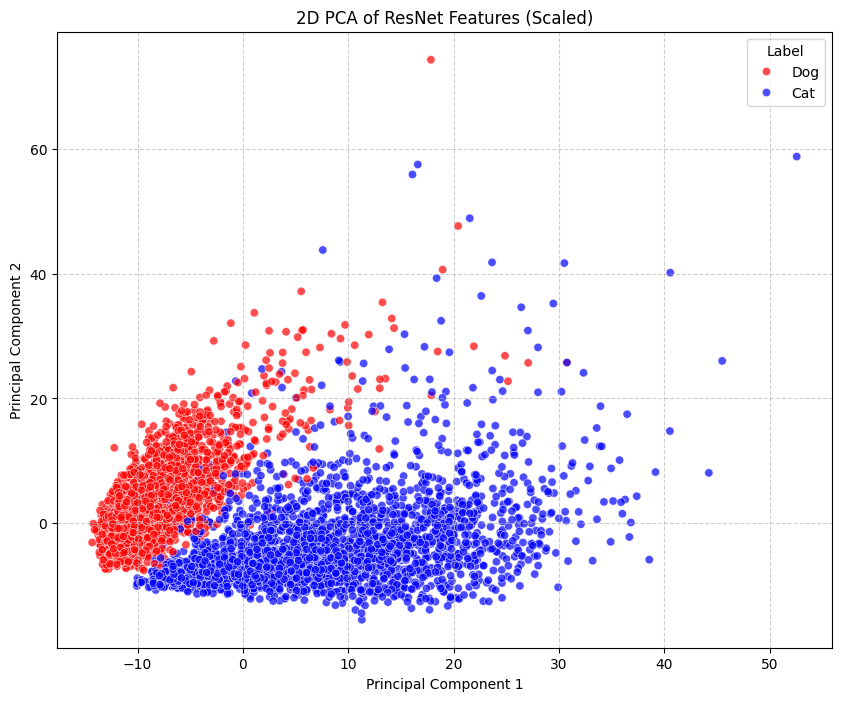

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(feature_vector_scaled_df.drop('Label', axis=1))

# Create a DataFrame for the 2D PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Label'] = feature_vector_scaled_df['Label'].reset_index(drop=True)

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Label',
    data=pca_df,
    palette={'Cat': 'blue', 'Dog': 'red'},
    alpha=0.7
)
plt.title('2D PCA of ResNet Features (Scaled)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Clustering

## Clustering with 100 PC's

In [22]:
cluster_df = pd.read_csv(save_path)
cluster_df.shape

(4964, 102)

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score

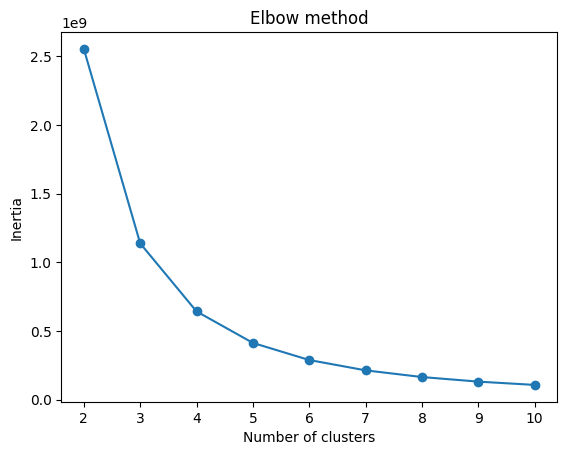

In [24]:
inertias = []
sil_score =[]
db_score =[]
results = []
xcluster_df = cluster_df.iloc[:,:-1]
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(xcluster_df)
    score = silhouette_score(xcluster_df,kmeans.labels_)
    db_index = davies_bouldin_score(xcluster_df, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)
    results.append({
        "n_clusters": i,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(xcluster_df, kmeans.labels_),
        "davies_bouldin": davies_bouldin_score(xcluster_df, kmeans.labels_)
    })
results_df = pd.DataFrame(results)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [25]:
results_df

,n_clusters,inertia,silhouette,davies_bouldin
0,2,2.552701e+09,0.625439,0.501429
1,3,1.136978e+09,0.587504,0.502749
2,4,6.414639e+08,0.567553,0.504545
3,5,4.121349e+08,0.554563,0.506891
4,6,2.875454e+08,0.544959,0.509809
5,7,2.124224e+08,0.537240,0.512558
6,8,1.636872e+08,0.530776,0.515235
7,9,1.302791e+08,0.524900,0.518670
8,10,1.063409e+08,0.519539,0.522418


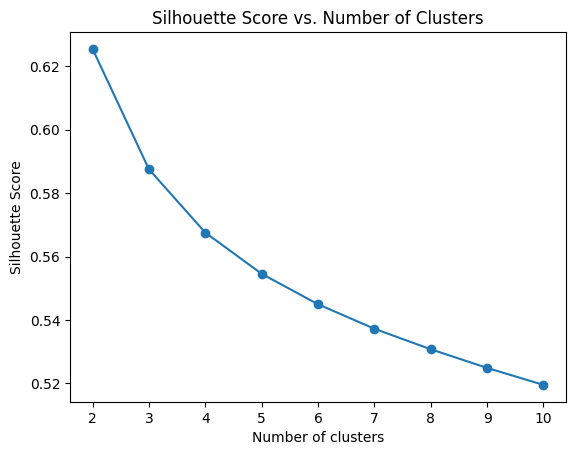

In [26]:
plt.plot(range(2,11), sil_score, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

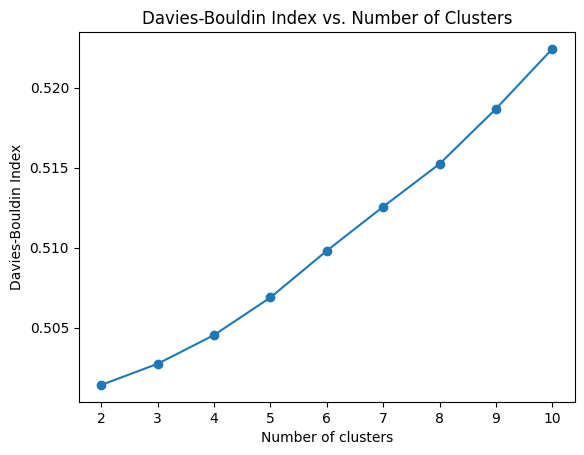

In [27]:
plt.plot(range(2,11), db_score, marker='o')
plt.title('Davies-Bouldin Index vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

## Clustering with 50 PC's

(4964, 50)


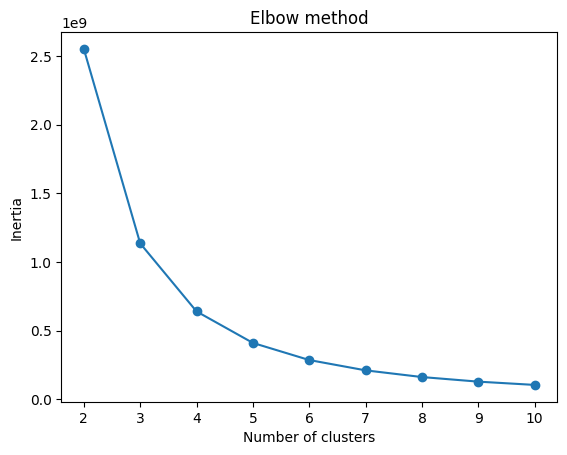

In [28]:
inertias = []
sil_score =[]
db_score =[]
results = []
xcluster_df = cluster_df.iloc[:,:50]
print(xcluster_df.shape)
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(xcluster_df)
    score = silhouette_score(xcluster_df,kmeans.labels_)
    db_index = davies_bouldin_score(xcluster_df, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)
    results.append({
        "n_clusters": i,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(xcluster_df, kmeans.labels_),
        "davies_bouldin": davies_bouldin_score(xcluster_df, kmeans.labels_)
    })
results_df = pd.DataFrame(results)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [29]:
results_df

,n_clusters,inertia,silhouette,davies_bouldin
0,2,2.551704e+09,0.625671,0.501133
1,3,1.135981e+09,0.587991,0.502197
2,4,6.404821e+08,0.568339,0.503625
3,5,4.111691e+08,0.555714,0.505510
4,6,2.865665e+08,0.546525,0.507843
5,7,2.114611e+08,0.539242,0.510075
6,8,1.627311e+08,0.533209,0.512248
7,9,1.292834e+08,0.527832,0.515043
8,10,1.054443e+08,0.522930,0.518082


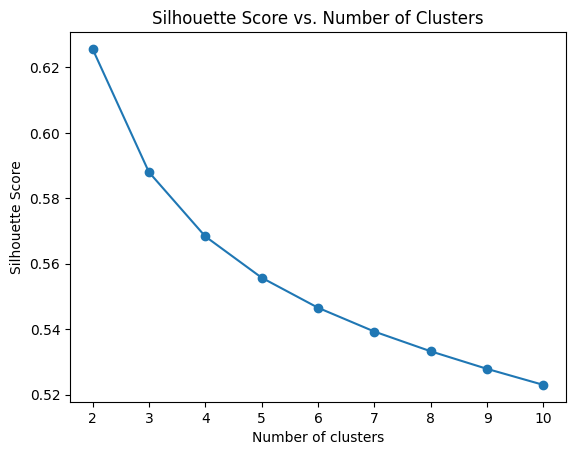

In [30]:
plt.plot(range(2,11), sil_score, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

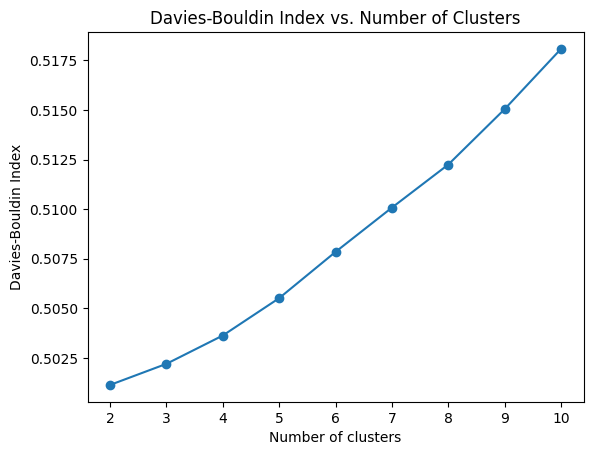

In [31]:
plt.plot(range(2,11), db_score, marker='o')
plt.title('Davies-Bouldin Index vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

## Clustering with 20 PC's

(4964, 20)


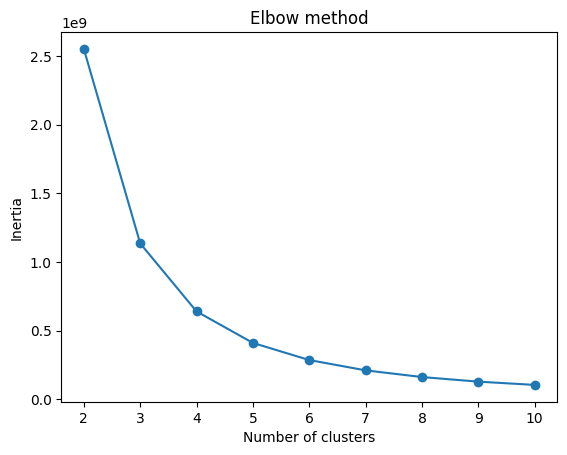

In [32]:
inertias = []
sil_score =[]
db_score =[]
results = []
xcluster_df = cluster_df.iloc[:,:20]
print(xcluster_df.shape)
for i in range(2,11):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(xcluster_df)
    score = silhouette_score(xcluster_df,kmeans.labels_)
    db_index = davies_bouldin_score(xcluster_df, kmeans.labels_)
    inertias.append(kmeans.inertia_)
    sil_score.append(score)
    db_score.append(db_index)
    results.append({
        "n_clusters": i,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(xcluster_df, kmeans.labels_),
        "davies_bouldin": davies_bouldin_score(xcluster_df, kmeans.labels_)
    })
results_df = pd.DataFrame(results)
plt.plot(range(2,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [33]:
results_df

,n_clusters,inertia,silhouette,davies_bouldin
0,2,2.550649e+09,0.625928,0.500808
1,3,1.134944e+09,0.588535,0.501582
2,4,6.394533e+08,0.569223,0.502607
3,5,4.101736e+08,0.557008,0.503974
4,6,2.855880e+08,0.548279,0.505669
5,7,2.104808e+08,0.541514,0.507317
6,8,1.617755e+08,0.535982,0.508913
7,9,1.283537e+08,0.531153,0.510952
8,10,1.044952e+08,0.526838,0.513257


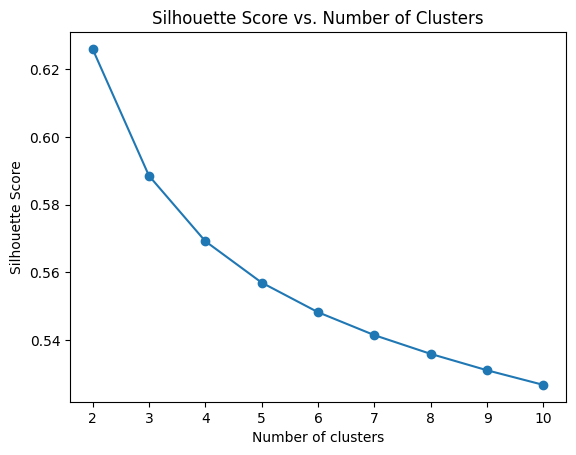

In [34]:
plt.plot(range(2,11), sil_score, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

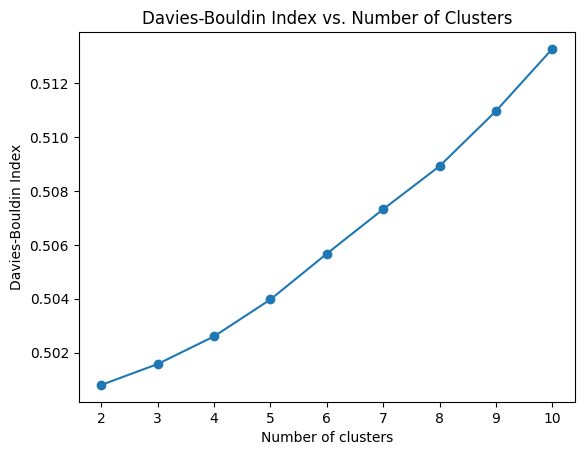

In [35]:
plt.plot(range(2,11), db_score, marker='o')
plt.title('Davies-Bouldin Index vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

## Cluster Visualization

In [36]:
cluster_df['Label'].value_counts()


,count
Label,
Cat,2486
Dog,2478


In [37]:
cluster_df.head(10)

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,91,92,93,94,95,96,97,98,99,Label
0,0,-8.867629,9.300080,-1.924502,-0.488155,5.406920,-2.656357,-2.855594,-1.819389,0.370197,...,2.192972,-0.673101,-0.923655,-1.800712,0.646904,-4.340531,-0.792298,-0.290266,-1.596189,Dog
1,1,8.253784,-7.810442,-0.034722,-4.022790,8.200381,-0.683422,1.135136,1.621848,-2.600962,...,0.648819,0.385024,-2.207839,-0.931587,-1.269433,-0.236707,-1.879144,0.751255,-0.839478,Cat
2,2,-12.398877,-3.409748,0.053082,2.964998,-1.548754,0.948414,-3.012679,-1.646530,-1.936318,...,1.211351,-0.020061,-0.010133,-0.983130,0.038052,0.014151,-0.685149,0.533732,0.856223,Dog
3,3,-7.875029,-0.424588,0.073502,3.637701,-0.584233,-1.121139,-1.221675,-6.427824,2.142311,...,-0.288009,1.238028,1.616374,-0.706413,0.819201,0.724301,2.701120,-1.546795,-0.561266,Dog
4,4,-5.272221,-7.729857,-0.570616,-7.472753,-2.594780,1.927113,0.362022,1.999550,-0.088044,...,-1.297618,-0.734417,1.064770,1.562945,-0.773432,-2.540358,1.717475,0.924346,-0.822547,Cat
5,5,-9.728996,-0.910917,2.740247,-3.880582,-0.574139,6.158630,7.547872,-1.356254,5.789523,...,-1.862954,-0.430018,0.708309,-0.026328,1.312426,0.147380,1.087558,1.077205,0.334131,Dog
6,6,19.708020,-12.340783,-13.246965,-5.557963,-1.219237,-1.055352,-1.056078,2.953606,1.843335,...,4.196940,0.061651,0.835462,2.036629,0.708199,-1.050584,1.984765,-0.220885,1.109748,Cat
7,7,7.574076,43.808903,47.235161,-12.581321,7.281885,-14.544982,-18.849307,-4.487922,7.875289,...,0.190926,4.667088,-7.748667,-0.180013,-7.283696,0.842470,-4.087531,-0.427952,3.440090,Cat
8,8,-12.052972,-1.203956,0.628411,-1.334650,2.908806,0.962499,-0.604111,-3.467689,-5.115135,...,-0.291041,-1.189292,-2.258131,-0.512146,-0.526735,-0.493455,-1.987542,0.266496,-0.186281,Dog
9,9,-4.615097,7.677895,-2.475555,-8.829607,3.219734,2.660233,-5.974126,4.334882,-1.614523,...,1.238478,0.526647,0.334254,3.881050,-4.235322,-0.267786,-2.359099,2.750763,-2.318263,Dog


In [38]:
cluster_df.iloc[:,:2]

,Unnamed: 0,0
0,0,-8.867629
1,1,8.253784
2,2,-12.398877
3,3,-7.875029
4,4,-5.272221
...,...,...
4959,4959,-5.803147
4960,4960,-11.301574
4961,4961,-11.709142
4962,4962,6.327232


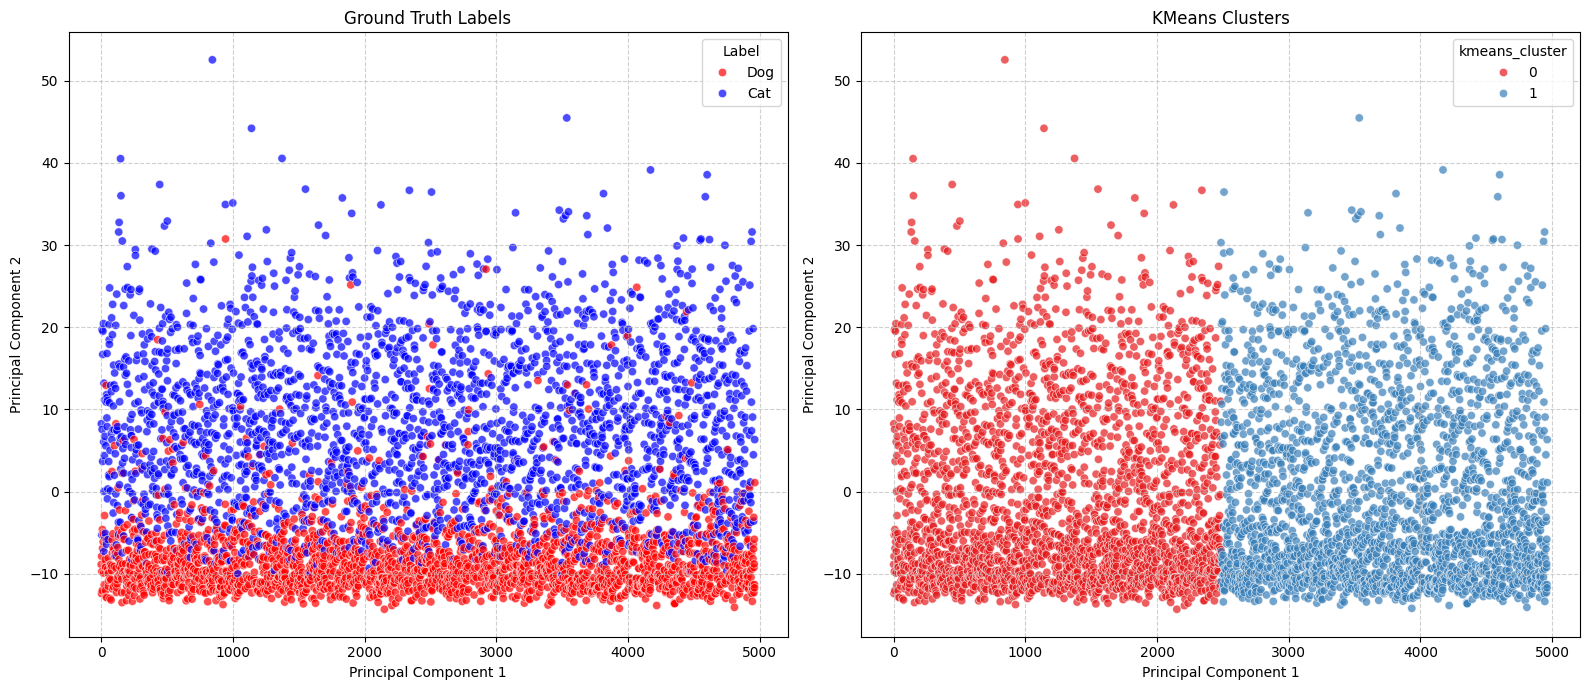

In [39]:
# Prepare small PCA DataFrame
pca_df = cluster_df.iloc[:, :2].copy()
pca_df.columns = ['Principal Component 1', 'Principal Component 2']
pca_df['Label'] = cluster_df['Label'].values

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
pca_df['kmeans_cluster'] = kmeans.fit_predict(pca_df[['Principal Component 1', 'Principal Component 2']])

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Ground truth labels
sns.scatterplot(
    data=pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Label',
    palette={'Cat': 'blue', 'Dog': 'red'},
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Ground Truth Labels')
axes[0].grid(True, linestyle='--', alpha=0.6)

# KMeans clusters
sns.scatterplot(
    data=pca_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='kmeans_cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('KMeans Clusters')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Classification

## SVM with 100 PC's

Firstly using 100 features

In [40]:
classification_df = pd.read_csv(save_path)
classification_df.shape

(4964, 102)

In [41]:
X= classification_df.iloc[:,:-1]
y = classification_df.iloc[:,-1]

In [42]:
print(y.head())

0    Dog
1    Cat
2    Dog
3    Dog
4    Cat
Name: Label, dtype: object


In [43]:
print(X.head(2))

   Unnamed: 0         0         1         2         3         4         5  \
0           0 -8.867629  9.300080 -1.924502 -0.488155  5.406920 -2.656357   
1           1  8.253784 -7.810442 -0.034722 -4.022790  8.200381 -0.683422   

          6         7         8  ...        90        91        92        93  \
0 -2.855594 -1.819389  0.370197  ...  2.533060  2.192972 -0.673101 -0.923655   
1  1.135136  1.621848 -2.600962  ...  1.534449  0.648819  0.385024 -2.207839   

         94        95        96        97        98        99  
0 -1.800712  0.646904 -4.340531 -0.792298 -0.290266 -1.596189  
1 -0.931587 -1.269433 -0.236707 -1.879144  0.751255 -0.839478  

[2 rows x 101 columns]


In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=1.0) # RBF kernel is standard for "feature" vectors
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Training SVM...


In [46]:
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
Accuracy: 0.5065
              precision    recall  f1-score   support

         Cat       0.50      0.99      0.66       492
         Dog       0.72      0.04      0.07       501

    accuracy                           0.51       993
   macro avg       0.61      0.51      0.37       993
weighted avg       0.61      0.51      0.36       993



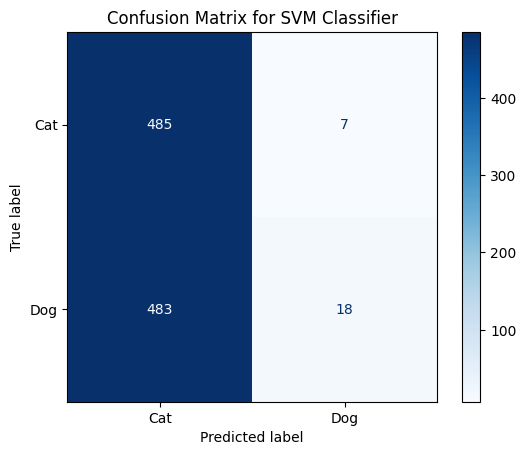

In [47]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVM Classifier')
plt.grid(False) # Remove grid for cleaner confusion matrix
plt.show()


## SVM with 50 PC's

In [48]:
X= classification_df.iloc[:,:50]
y = classification_df.iloc[:,-1]

In [49]:
print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)

(4964, 50)
(3971, 50)


In [50]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=1.0) # RBF kernel is standard for "feature" vectors
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Training SVM...


In [51]:
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
Accuracy: 0.5045
              precision    recall  f1-score   support

         Cat       0.50      0.98      0.66       492
         Dog       0.66      0.04      0.07       501

    accuracy                           0.50       993
   macro avg       0.58      0.51      0.37       993
weighted avg       0.58      0.50      0.36       993



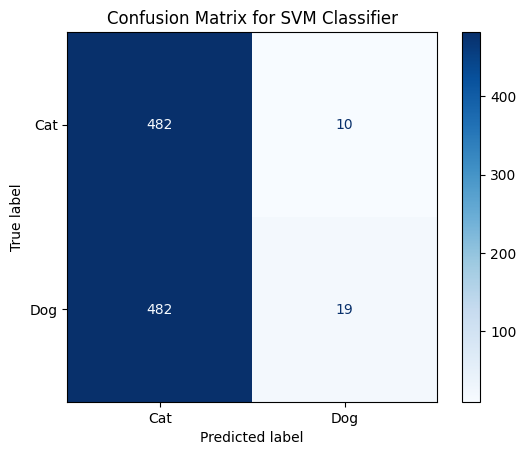

In [52]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVM Classifier')
plt.grid(False) # Remove grid for cleaner confusion matrix
plt.show()

## SVM with 20 PC's

In [53]:
X= classification_df.iloc[:,:20]
y = classification_df.iloc[:,-1]

In [54]:
print(X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(4964, 20)


In [55]:
print("Training SVM...")
svm = SVC(kernel='rbf', C=1.0) # RBF kernel is standard for "feature" vectors
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

Training SVM...


In [56]:
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm))


--- SVM Results ---
Accuracy: 0.5106
              precision    recall  f1-score   support

         Cat       0.50      0.97      0.66       492
         Dog       0.67      0.06      0.11       501

    accuracy                           0.51       993
   macro avg       0.59      0.51      0.38       993
weighted avg       0.59      0.51      0.38       993



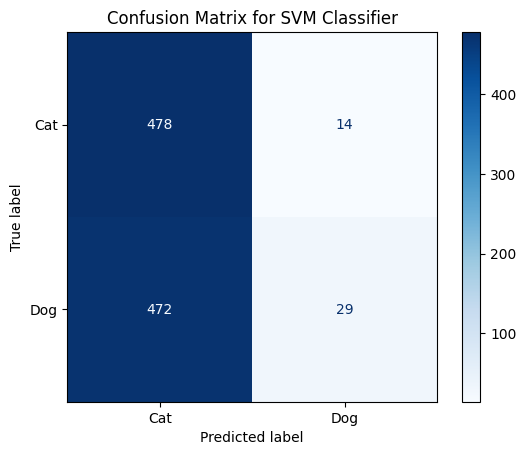

In [57]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=svm.classes_)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVM Classifier')
plt.grid(False) # Remove grid for cleaner confusion matrix
plt.show()

## Using Linear Layer

In [58]:
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [59]:
# Features and labels
X = feature_vector_scaled_df.iloc[:, :-1].values.astype(float)
y = feature_vector_scaled_df.iloc[:, -1].values  # likely strings

# Convert string labels to integers
le = LabelEncoder()
y = le.fit_transform(y)  # now y is integer 0..num_classes-1

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: torch.Size([3971, 2048]), y_train shape: torch.Size([3971])
X_test shape: torch.Size([993, 2048]), y_test shape: torch.Size([993])


In [60]:
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

### defining linear layer

In [61]:
num_features = 2048
num_classes = len(torch.unique(y_train))

linear_layer = nn.Linear(num_features, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(linear_layer.parameters(), lr=1e-3)


### training linear layer

In [62]:
linear_layer.train()

loss_history = [] # Store loss for plotting

for epoch in range(20):
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = linear_layer(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_history.append(total_loss)
    print(f"Epoch {epoch+1}/20 - Loss: {total_loss:.4f}")


Epoch 1/20 - Loss: 5.2091
Epoch 2/20 - Loss: 0.8959
Epoch 3/20 - Loss: 0.4213
Epoch 4/20 - Loss: 0.4083
Epoch 5/20 - Loss: 0.2725
Epoch 6/20 - Loss: 0.2612
Epoch 7/20 - Loss: 0.3927
Epoch 8/20 - Loss: 0.2144
Epoch 9/20 - Loss: 0.3787
Epoch 10/20 - Loss: 0.2228
Epoch 11/20 - Loss: 0.2115
Epoch 12/20 - Loss: 0.3691
Epoch 13/20 - Loss: 0.3042
Epoch 14/20 - Loss: 0.2726
Epoch 15/20 - Loss: 0.1963
Epoch 16/20 - Loss: 0.2600
Epoch 17/20 - Loss: 0.2177
Epoch 18/20 - Loss: 0.3443
Epoch 19/20 - Loss: 0.0961
Epoch 20/20 - Loss: 0.3610


### training loss per epoch

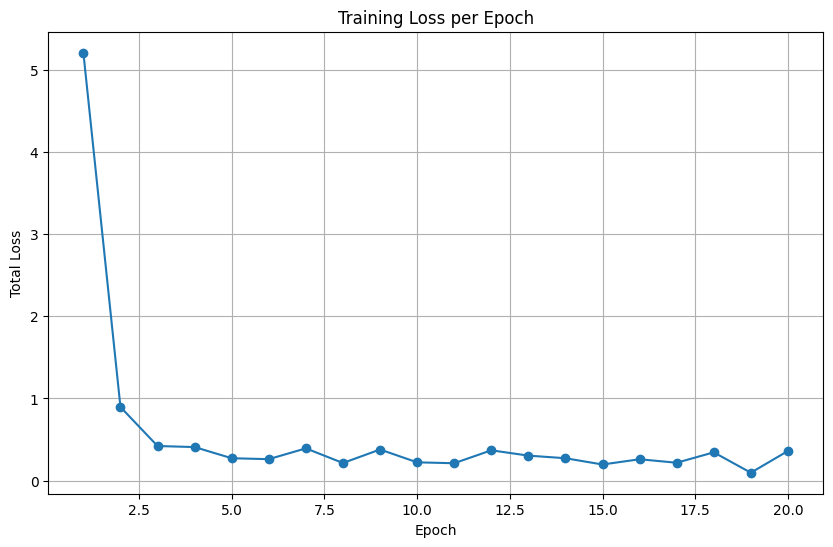

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linestyle='-')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True)
plt.show()


### evaluation

In [64]:
linear_layer.eval()
with torch.no_grad():
    logits = linear_layer(X_test)
    preds = torch.argmax(logits, dim=1)

accuracy = (preds == y_test).float().mean().item()
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9950


Confusion Matrix:
 [[494   3]
 [  2 494]]


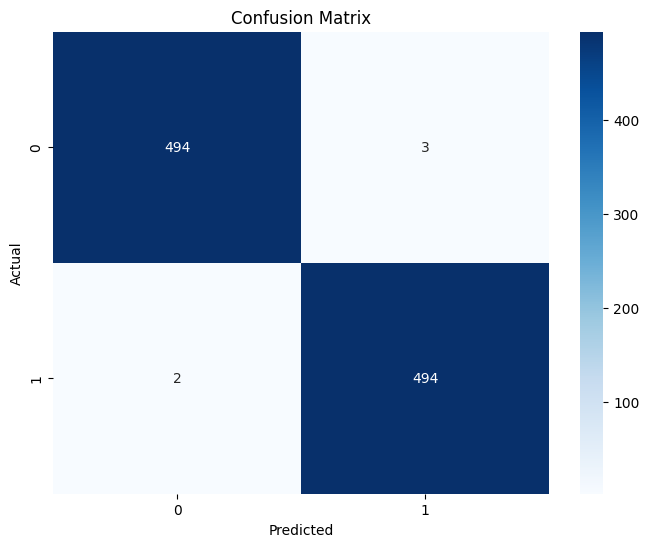

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       497
           1       0.99      1.00      0.99       496

    accuracy                           0.99       993
   macro avg       0.99      0.99      0.99       993
weighted avg       0.99      0.99      0.99       993



In [65]:
y_true = y_test.numpy()
y_pred = preds.numpy()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Optional: plot confusion matrix nicely
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred)
print("Classification Report:\n", report)